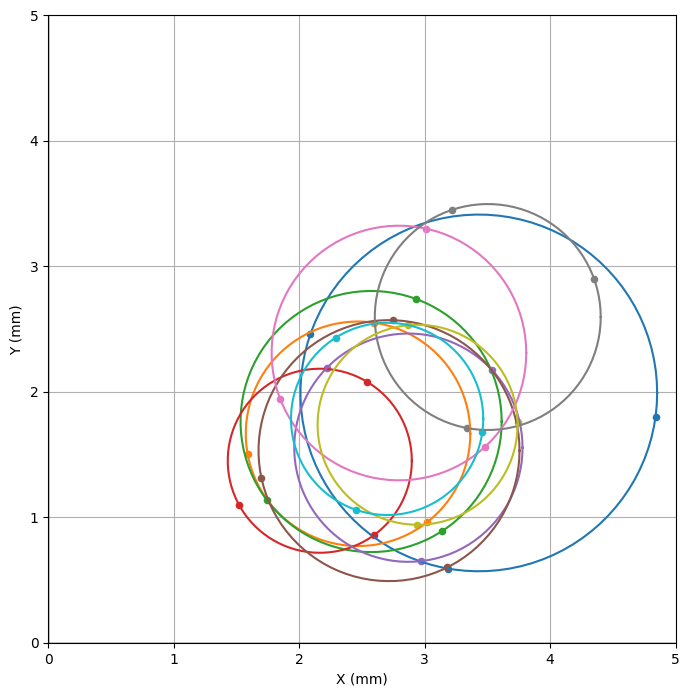

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fonction pour calculer un cercle à partir de 3 points 2D
def calculate_circle_2d(points):
    p1, p2, p3 = points
    
    # Calcul des médiatrices
    mid1 = (p1 + p2) / 2
    mid2 = (p1 + p3) / 2
    perp1 = np.array([-(p2[1] - p1[1]), p2[0] - p1[0]])  # Vecteur perpendiculaire à p1-p2
    perp2 = np.array([-(p3[1] - p1[1]), p3[0] - p1[0]])  # Vecteur perpendiculaire à p1-p3
    
    # Résolution du système d'équations pour trouver le centre
    A = np.array([perp1, -perp2]).T
    b = mid2 - mid1
    t = np.linalg.lstsq(A, b, rcond=None)[0]
    center = mid1 + t[0] * perp1

    # Rayon du cercle
    radius = np.linalg.norm(center - p1)
    
    return center, radius

# Fonction pour générer les points d'un cercle 2D
def generate_circle_2d(center, radius, num_points=100):
    angles = np.linspace(0, 2 * np.pi, num_points)
    circle_points = np.array([ 
        [center[0] + radius * np.cos(angle), center[1] + radius * np.sin(angle)] 
        for angle in angles 
    ])
    return circle_points

# Charger les données à partir du fichier Excel
file_path = r'G:\PhD\Experimentation\Calcium_imaging_WF\analysis_DFF\coordinates_analysis\coordinates\coordinates_map.xlsx'  # Remplacez par le chemin de votre fichier
data = pd.read_excel(file_path)

# Initialiser la figure
fig, ax = plt.subplots(figsize=(7, 7))

# Couleurs pour les animaux (en utilisant matplotlib.colormaps.get_cmap)
colors = plt.get_cmap("tab10", len(data))

# Traiter les données pour chaque animal
for i, row in data.iterrows():
    animal = row['Animal']
    
    # Coordonnées du bregma
    Bx, By, Bz = row['Bx'], row['By'], row['Bz']
    
    # Points pour la zone d'enregistrement (normalisés par rapport au bregma et Bz)
    points = np.array([
        [row['C1x'], row['C1y']],
        [row['C2x'], row['C2y']],
        [row['C3x'], row['C3y']]
    ])
    
    # Calculer le cercle
    center, radius = calculate_circle_2d(points)
    circle_points = generate_circle_2d(center, radius)
    
    # Ajouter le cercle
    ax.plot(circle_points[:, 0], circle_points[:, 1], c=colors(i), label=f'{animal} (cercle)')
    
    # Ajouter les points normalisés
    ax.scatter(points[:, 0], points[:, 1], c=[colors(i)], label=f'{animal} (points)', s=20)

# Ajouter des étiquettes et une légende
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')

# Définir les limites des axes manuellement pour que l'axe X soit de -5 à 5 et Y de 5 à -5
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)

# Garder les proportions égales et les limites des axes
ax.set_aspect('equal', 'box')  # Cela garantit que les axes ont la même échelle

# Activer la grille
ax.grid(True)

# Ajouter des axes passant par le centre
ax.axhline(0, color='black',linewidth=1)  # Axe X
ax.axvline(0, color='black',linewidth=1)  # Axe Y



# Définir les ticks (graduations) sur les axes X et Y avec un pas de 1
ax.set_xticks(np.arange(0, 6, 1))
ax.set_yticks(np.arange(0, 6, 1))

# Ajuster l'espace pour éviter que la légende ne déforme la figure
plt.subplots_adjust(right=0.85)

# Afficher le graphique
plt.tight_layout()
plt.show()


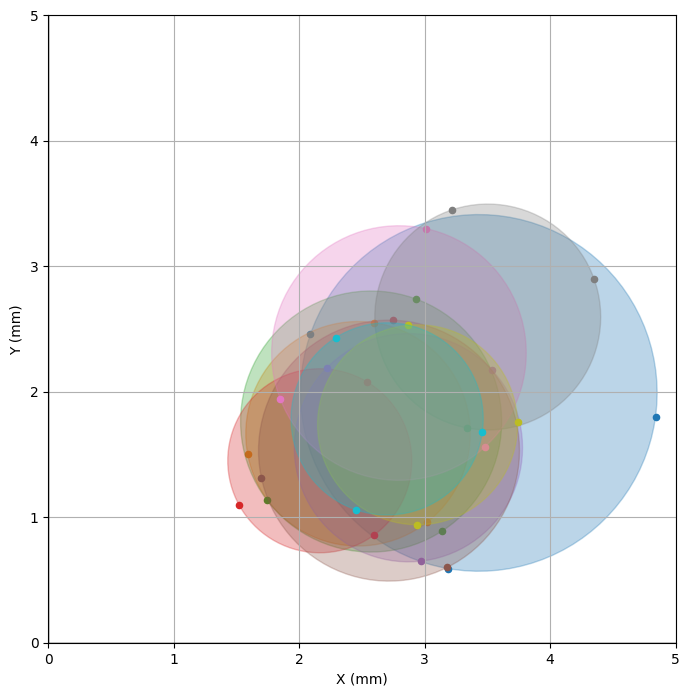

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fonction pour calculer un cercle à partir de 3 points 2D
def calculate_circle_2d(points):
    p1, p2, p3 = points
    
    # Calcul des médiatrices
    mid1 = (p1 + p2) / 2
    mid2 = (p1 + p3) / 2
    perp1 = np.array([-(p2[1] - p1[1]), p2[0] - p1[0]])  # Vecteur perpendiculaire à p1-p2
    perp2 = np.array([-(p3[1] - p1[1]), p3[0] - p1[0]])  # Vecteur perpendiculaire à p1-p3
    
    # Résolution du système d'équations pour trouver le centre
    A = np.array([perp1, -perp2]).T
    b = mid2 - mid1
    t = np.linalg.lstsq(A, b, rcond=None)[0]
    center = mid1 + t[0] * perp1

    # Rayon du cercle
    radius = np.linalg.norm(center - p1)
    
    return center, radius

# Fonction pour générer les points d'un cercle 2D
def generate_circle_2d(center, radius, num_points=100):
    angles = np.linspace(0, 2 * np.pi, num_points)
    circle_points = np.array([ 
        [center[0] + radius * np.cos(angle), center[1] + radius * np.sin(angle)] 
        for angle in angles 
    ])
    return circle_points

# Charger les données à partir du fichier Excel
file_path = r'G:\PhD\Experimentation\Calcium_imaging_WF\analysis_DFF\coordinates_analysis\coordinates\coordinates_map.xlsx'  # Remplacez par le chemin de votre fichier
data = pd.read_excel(file_path)

# Initialiser la figure
fig, ax = plt.subplots(figsize=(7, 7))

# Couleurs pour les animaux (en utilisant matplotlib.colormaps.get_cmap)
colors = plt.get_cmap("tab10", len(data))

# Traiter les données pour chaque animal
for i, row in data.iterrows():
    animal = row['Animal']
    
    # Coordonnées du bregma
    Bx, By, Bz = row['Bx'], row['By'], row['Bz']
    
    # Points pour la zone d'enregistrement (normalisés par rapport au bregma et Bz)
    points = np.array([
        [row['C1x'], row['C1y']],
        [row['C2x'], row['C2y']],
        [row['C3x'], row['C3y']]
    ])
    
    # Calculer le cercle
    center, radius = calculate_circle_2d(points)
    circle_points = generate_circle_2d(center, radius)
    
    # Ajouter le cercle avec un remplissage transparent
    ax.fill(circle_points[:, 0], circle_points[:, 1], color=colors(i), alpha=0.3, label=f'{animal} (cercle)')
    
    # Ajouter les points normalisés
    ax.scatter(points[:, 0], points[:, 1], c=[colors(i)], label=f'{animal} (points)', s=20)

# Ajouter des étiquettes et une légende
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')

# Définir les limites des axes manuellement pour que l'axe X soit de -5 à 5 et Y de 5 à -5
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)

# Garder les proportions égales et les limites des axes
ax.set_aspect('equal', 'box')  # Cela garantit que les axes ont la même échelle

# Activer la grille
ax.grid(True)

# Ajouter des axes passant par le centre
ax.axhline(0, color='black',linewidth=1)  # Axe X
ax.axvline(0, color='black',linewidth=1)  # Axe Y

# Définir les ticks (graduations) sur les axes X et Y avec un pas de 1
ax.set_xticks(np.arange(0, 6, 1))
ax.set_yticks(np.arange(0, 6, 1))

# Ajuster l'espace pour éviter que la légende ne déforme la figure
plt.subplots_adjust(right=0.85)

# Afficher le graphique
plt.tight_layout()
plt.show()


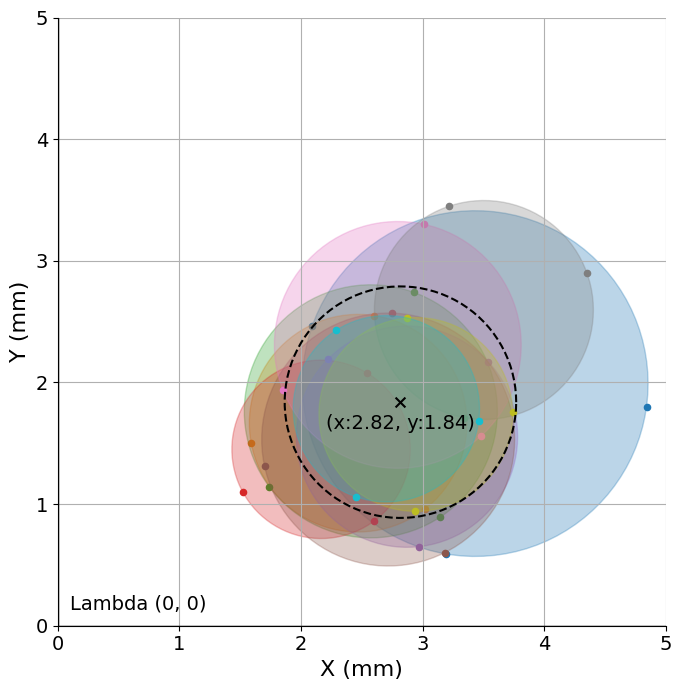

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Fonction pour calculer un cercle à partir de 3 points 2D
def calculate_circle_2d(points):
    p1, p2, p3 = points
    
    # Calcul des médiatrices
    mid1 = (p1 + p2) / 2
    mid2 = (p1 + p3) / 2
    perp1 = np.array([-(p2[1] - p1[1]), p2[0] - p1[0]])  # Vecteur perpendiculaire à p1-p2
    perp2 = np.array([-(p3[1] - p1[1]), p3[0] - p1[0]])  # Vecteur perpendiculaire à p1-p3
    
    # Résolution du système d'équations pour trouver le centre
    A = np.array([perp1, -perp2]).T
    b = mid2 - mid1
    t = np.linalg.lstsq(A, b, rcond=None)[0]
    center = mid1 + t[0] * perp1

    # Rayon du cercle
    radius = np.linalg.norm(center - p1)
    
    return center, radius

# Fonction pour générer les points d'un cercle 2D
def generate_circle_2d(center, radius, num_points=100):
    angles = np.linspace(0, 2 * np.pi, num_points)
    circle_points = np.array([ 
        [center[0] + radius * np.cos(angle), center[1] + radius * np.sin(angle)] 
        for angle in angles 
    ])
    return circle_points

# Charger les données à partir du fichier Excel
file_path = r'G:\PhD\Experimentation\Calcium_imaging_WF\analysis_DFF\coordinates_analysis\coordinates\coordinates_map.xlsx'  # Remplacez par le chemin de votre fichier
data = pd.read_excel(file_path)

# Liste pour stocker les centres et rayons des cercles
centers = []
radii = []

# Initialiser la figure pour les cercles individuels
fig, ax = plt.subplots(figsize=(7, 7))

# Couleurs pour les animaux (en utilisant matplotlib.colormaps.get_cmap)
colors = plt.get_cmap("tab10", len(data))

# Traiter les données pour chaque animal
for i, row in data.iterrows():
    animal = row['Animal']
    
    # Coordonnées du bregma
    Bx, By, Bz = row['Bx'], row['By'], row['Bz']
    
    # Points pour la zone d'enregistrement (normalisés par rapport au bregma et Bz)
    points = np.array([
        [row['C1x'], row['C1y']],
        [row['C2x'], row['C2y']],
        [row['C3x'], row['C3y']]
    ])
    
    # Calculer le cercle
    center, radius = calculate_circle_2d(points)
    circle_points = generate_circle_2d(center, radius)
    
    # Ajouter le cercle avec un remplissage transparent
    ax.fill(circle_points[:, 0], circle_points[:, 1], color=colors(i), alpha=0.3, label=f'{animal} (cercle)')
    
    # Ajouter les points normalisés
    ax.scatter(points[:, 0], points[:, 1], c=[colors(i)], label=f'{animal} (points)', s=20)

    # Stocker les centres et les rayons pour calculer le cercle moyen
    centers.append(center)
    radii.append(radius)

# Calculer le centre moyen et le rayon moyen
mean_center = np.mean(centers, axis=0)
mean_radius = np.mean(radii)

# Générer les points du cercle moyen
mean_circle_points = generate_circle_2d(mean_center, mean_radius)

# Tracer le cercle moyen
ax.plot(mean_circle_points[:, 0], mean_circle_points[:, 1], color='black', linestyle='--', label='Cercle moyen', linewidth=1.5)

# Ajouter une croix au centre du cercle moyen
ax.scatter(mean_center[0], mean_center[1], color='black', s=50, marker='x', label=f'Centre moyen ({mean_center[0]:.2f}, {mean_center[1]:.2f})')

ax.text(mean_center[0], mean_center[1] - 0.1, f'(x:{mean_center[0]:.2f}, y:{mean_center[1]:.2f})', 
        color='black', fontsize=14, verticalalignment='top', horizontalalignment='center')


# Ajouter des étiquettes et une légende
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')

# Définir les limites des axes manuellement pour que l'axe X soit de 0 à 5 et Y de 0 à 5
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)

# Garder les proportions égales et les limites des axes
ax.set_aspect('equal', 'box')  # Cela garantit que les axes ont la même échelle

# Activer la grille
ax.grid(True)

# Ajouter des axes passant par le centre
ax.axhline(0, color='black',linewidth=1)  # Axe X
ax.axvline(0, color='black',linewidth=1)  # Axe Y

# Ajouter une annotation pour indiquer que le point (0, 0) correspond à Lambda
ax.text(0.1, 0.1, 'Lambda (0, 0)', color='black', fontsize=14, verticalalignment='bottom', horizontalalignment='left')

# Définir les ticks (graduations) sur les axes X et Y avec un pas de 1
ax.set_xticks(np.arange(0, 6, 1))
ax.set_yticks(np.arange(0, 6, 1))

#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.labelsize': 16,   # Taille des labels des axes
    'xtick.labelsize': 14,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 14,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 14   # Taille de la police de la légende
})

plt.tight_layout()

saving_dir = r'G:\PhD\Experimentation\Calcium_imaging_WF\analysis_DFF\coordinates_analysis\coordinates'

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'coordinates_mapping.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'coordinates_mapping.svg'), format='svg', dpi=300)

# Afficher le graphique
plt.show()
